<a href="https://colab.research.google.com/github/karib3/ML-Engineering/blob/main/Clustering/Comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Problem Statement:
Create customer groups from the provided data.

#Data Collection:

In [ ]:
import kagglehub
path = kagglehub.dataset_download("vjchoudhary7/customer-segmentation-tutorial-in-python")

100%|██████████| 1.55k/1.55k [00:00<00:00, 2.89MB/s]

Extracting files...


In [ ]:
actual_path = path + "/Mall_Customers.csv"

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv(actual_path)

#Exploratory Data Analysis (EDA):

In [ ]:
df.shape

(200, 5)

In [ ]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [ ]:
df.describe().T.round(1)

,count,mean,std,min,25%,50%,75%,max
CustomerID,200.0,100.5,57.9,1.0,50.8,100.5,150.2,200.0
Age,200.0,38.8,14.0,18.0,28.8,36.0,49.0,70.0
Annual Income (k$),200.0,60.6,26.3,15.0,41.5,61.5,78.0,137.0
Spending Score (1-100),200.0,50.2,25.8,1.0,34.8,50.0,73.0,99.0


In [ ]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
df.tail()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18
199,200,Male,30,137,83


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
info = pd.DataFrame({
    'dtypes': df.dtypes,
    'missing values': df.isna().sum(),
    'unique values': df.nunique()
}).sort_values(by='missing values', ascending=False)

info

,dtypes,missing values,unique values
CustomerID,int64,0,200
Gender,object,0,2
Age,int64,0,51
Annual Income (k$),int64,0,64
Spending Score (1-100),int64,0,84


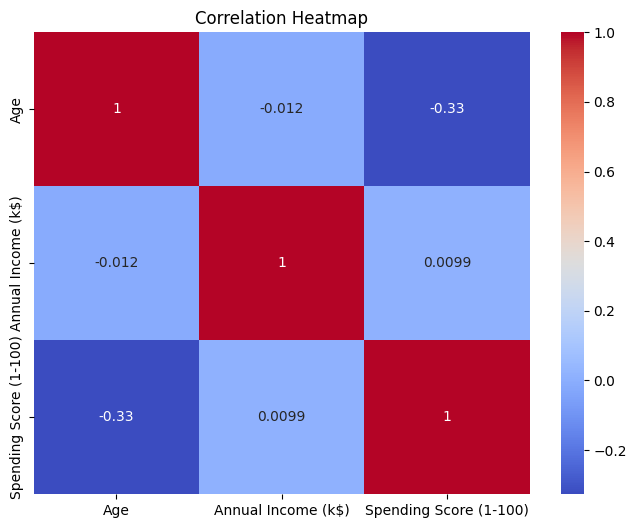

In [ ]:
numeric_df = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]

plt.figure(figsize=(8, 6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

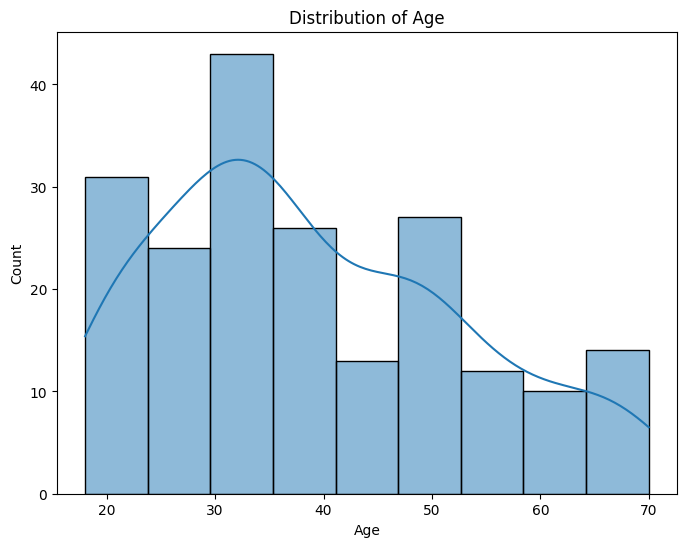

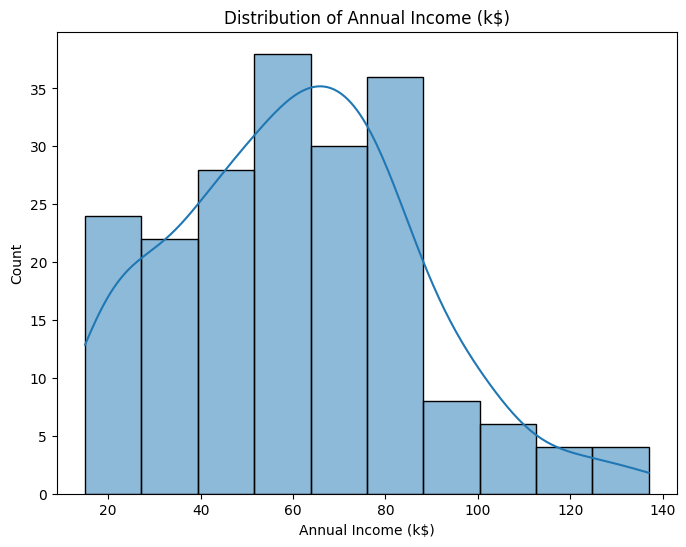

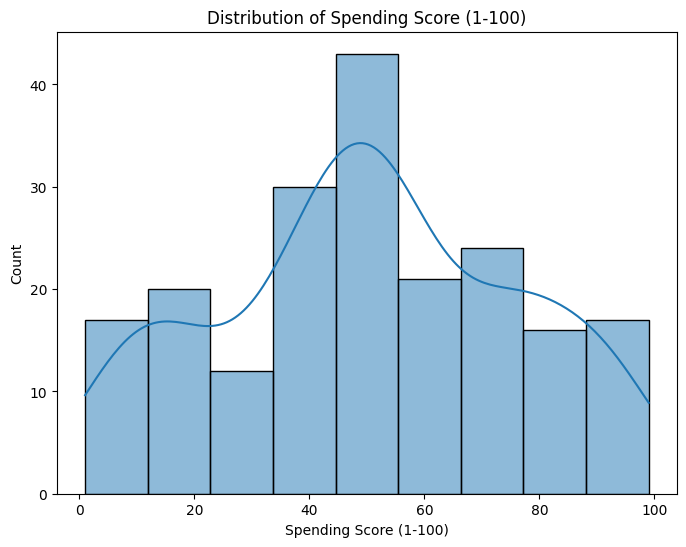

In [ ]:
for cols in numeric_df.columns:
    plt.figure(figsize=(8, 6))
    sns.histplot(df[cols], kde=True)
    plt.title(f'Distribution of {cols}')
    plt.show()

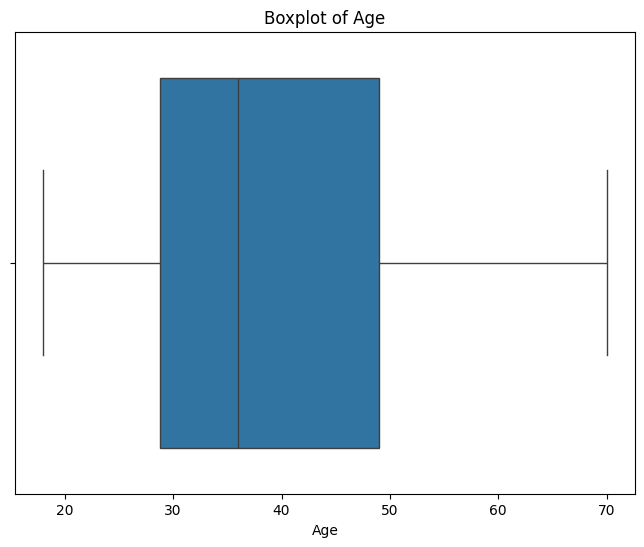

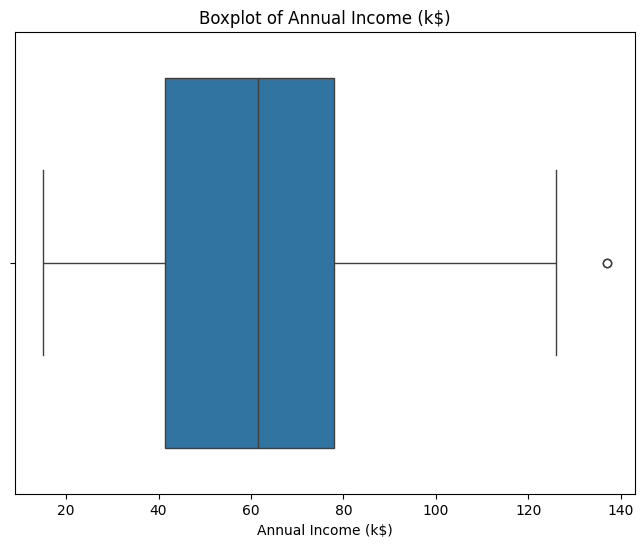

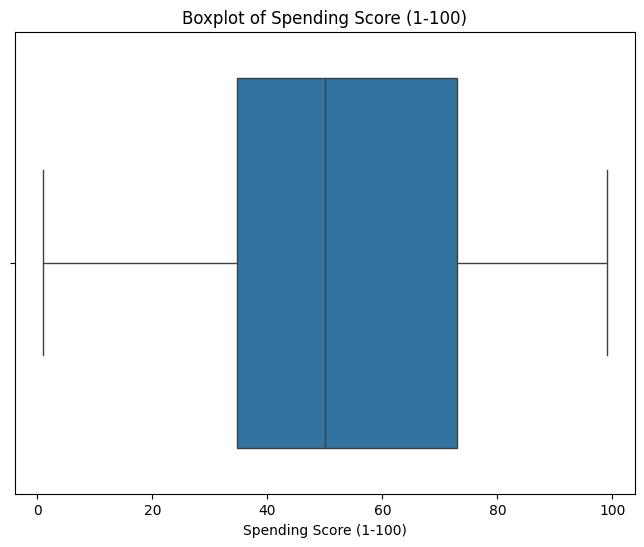

In [ ]:
for col in numeric_df.columns:
    plt.figure(figsize=(8, 6))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

<Figure size 800x600 with 0 Axes>

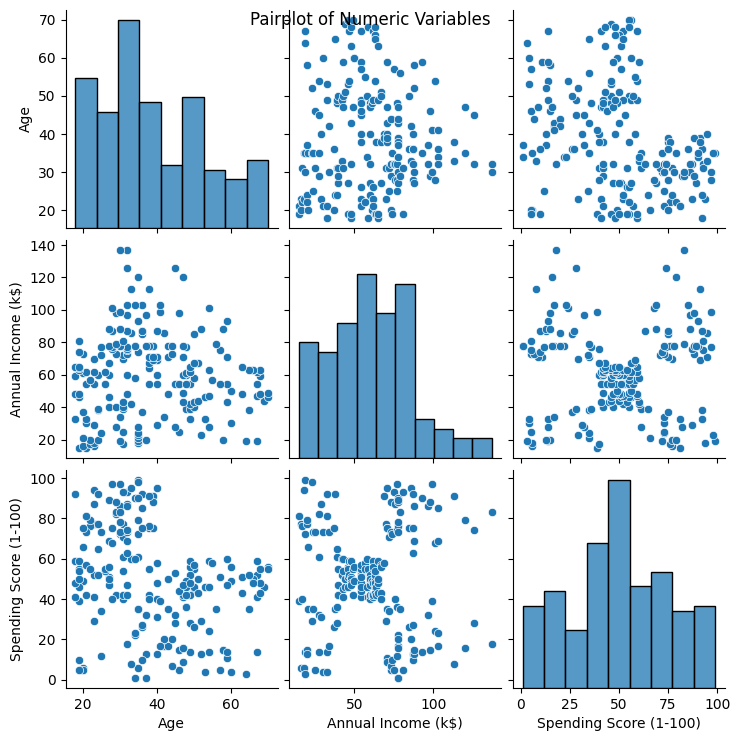

In [ ]:
plt.figure(figsize=(8, 6))
sns.pairplot(
    numeric_df,
    diag_kind='hist'
)
plt.suptitle('Pairplot of Numeric Variables')
plt.show()

In [ ]:
categorical_df = df['Gender']

categorical_df.value_counts(normalize=True)

,proportion
Gender,
Female,0.56
Male,0.44


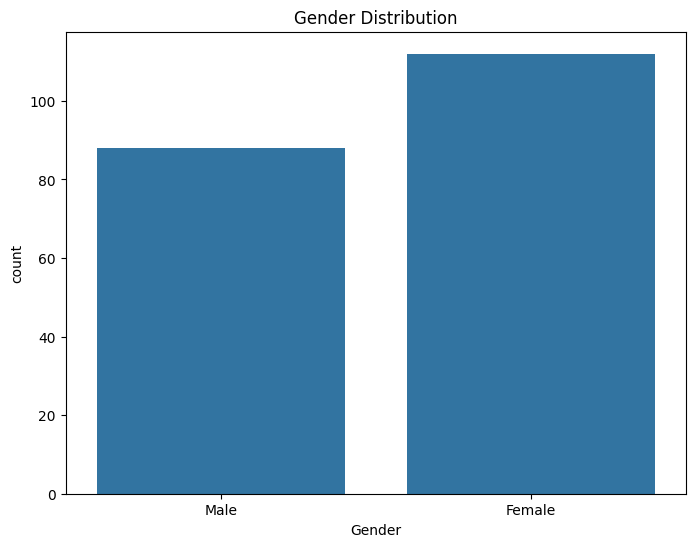

In [ ]:
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='Gender')
plt.title('Gender Distribution')
plt.show()

#Data Cleaning:

In [ ]:
df_clean = df.drop(columns=['CustomerID'], axis=1)
df_clean.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40


#Feature Selection:

In [ ]:
X = df_clean.drop(columns=['Gender'], axis=1)
X.head()

,Age,Annual Income (k$),Spending Score (1-100)
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40


#Preprocessing:

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(
    X_scaled,
    columns=['Age',
    'Annual Income (k$)',
    'Spending Score (1-100)'],
    index=X.index
)

X_scaled.head()

,Age,Annual Income (k$),Spending Score (1-100)
0,-1.424569,-1.738999,-0.434801
1,-1.281035,-1.738999,1.195704
2,-1.352802,-1.700830,-1.715913
3,-1.137502,-1.700830,1.040418
4,-0.563369,-1.662660,-0.395980


In [ ]:
X_scaled.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Age,200.0,-0.0,1.0,-1.50,-0.72,-0.20,0.73,2.24
Annual Income (k$),200.0,-0.0,1.0,-1.74,-0.73,0.04,0.67,2.92
Spending Score (1-100),200.0,-0.0,1.0,-1.91,-0.60,-0.01,0.89,1.89


#Baseline Models Analysis:
##KMeans Clustering
Finding the right k value.

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertia = []
silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    inertia.append(kmeans.inertia_)

    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

In [ ]:
for k, value in zip(range(2, 11), inertia):
    print(f"K={k}: Inertia={value:.2f}")

K=2: Inertia=389.39
K=3: Inertia=295.21
K=4: Inertia=205.23
K=5: Inertia=168.25
K=6: Inertia=133.87
K=7: Inertia=117.01
K=8: Inertia=103.87
K=9: Inertia=93.09
K=10: Inertia=82.39


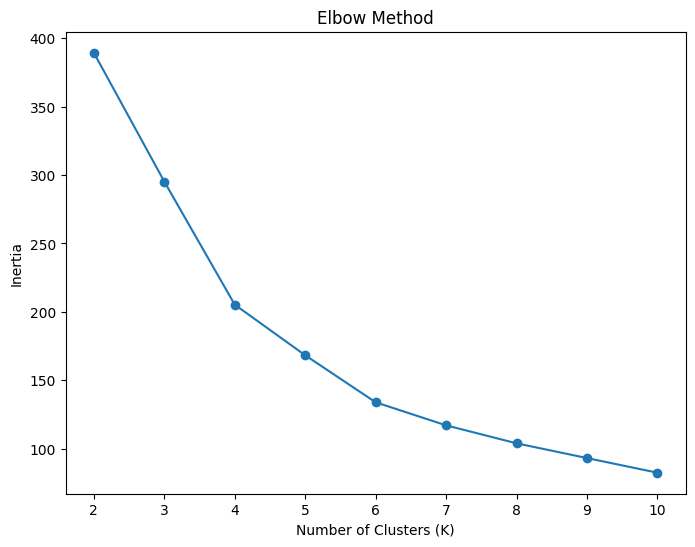

In [ ]:
plt.figure(figsize=(8, 6))

plt.plot(range(2, 11), inertia, marker='o')

plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method')

plt.show()

In [ ]:
for k, value in zip(range(2, 11), silhouette_scores):
    print(f"K={k}: Silhouette Score={value:.4f}")

K=2: Silhouette Score=0.3355
K=3: Silhouette Score=0.3578
K=4: Silhouette Score=0.4040
K=5: Silhouette Score=0.4166
K=6: Silhouette Score=0.4284
K=7: Silhouette Score=0.4172
K=8: Silhouette Score=0.4082
K=9: Silhouette Score=0.4177
K=10: Silhouette Score=0.4066


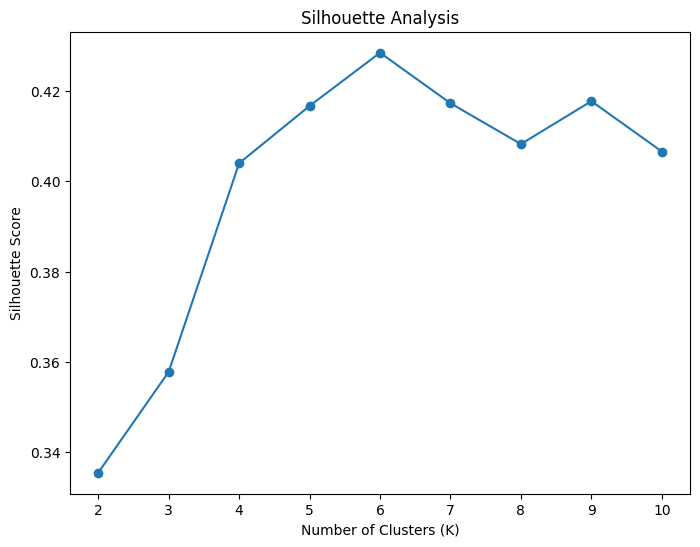

In [ ]:
plt.figure(figsize=(8, 6))

plt.plot(
    range(2, 11),
    silhouette_scores,
    marker='o'
)

plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Analysis')

plt.show()

In [ ]:
candidate_k = [4, 5, 6]

models = {}
labels_dict = {}

for k in candidate_k:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X_scaled)

    models[k] = model
    labels_dict[k] = labels

In [ ]:
from sklearn.metrics import (
    davies_bouldin_score,
    calinski_harabasz_score
)

for k in candidate_k:
    labels = labels_dict[k]

    silhouette = silhouette_score(X_scaled, labels)
    db = davies_bouldin_score(X_scaled, labels)
    ch = calinski_harabasz_score(X_scaled, labels)

    print(f"\nK={k}")
    print(f"Silhouette Score: {silhouette:.4f}")
    print(f"Davies-Bouldin Index: {db:.4f}")
    print(f"Calinski-Harabasz Index: {ch:.2f}")


K=4
Silhouette Score: 0.4040
Davies-Bouldin Index: 0.9308
Calinski-Harabasz Index: 125.68

K=5
Silhouette Score: 0.4166
Davies-Bouldin Index: 0.8746
Calinski-Harabasz Index: 125.10

K=6
Silhouette Score: 0.4284
Davies-Bouldin Index: 0.8254
Calinski-Harabasz Index: 135.10


In [ ]:
for k in candidate_k:
    labels = labels_dict[k]

    print(f"\nK={k}")
    print(pd.Series(labels).value_counts().sort_index())


K=4
0    65
1    40
2    57
3    38
Name: count, dtype: int64

K=5
0    20
1    54
2    40
3    39
4    47
Name: count, dtype: int64

K=6
0    45
1    39
2    33
3    39
4    23
5    21
Name: count, dtype: int64


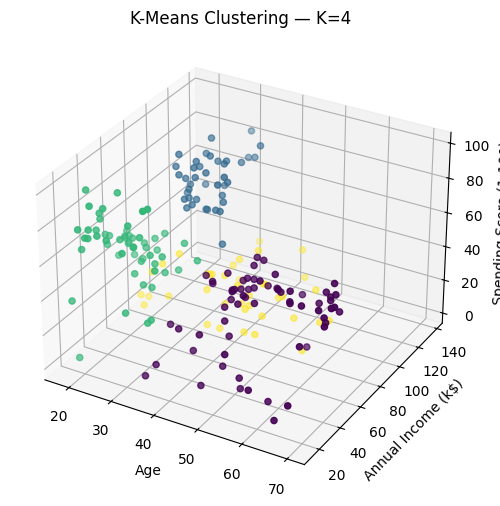

In [ ]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

labels = labels_dict[4]

ax.scatter(
    X['Age'],
    X['Annual Income (k$)'],
    X['Spending Score (1-100)'],
    c=labels
)

ax.set_xlabel('Age')
ax.set_ylabel('Annual Income (k$)')
ax.set_zlabel('Spending Score (1-100)')
ax.set_title('K-Means Clustering — K=4')

plt.show()

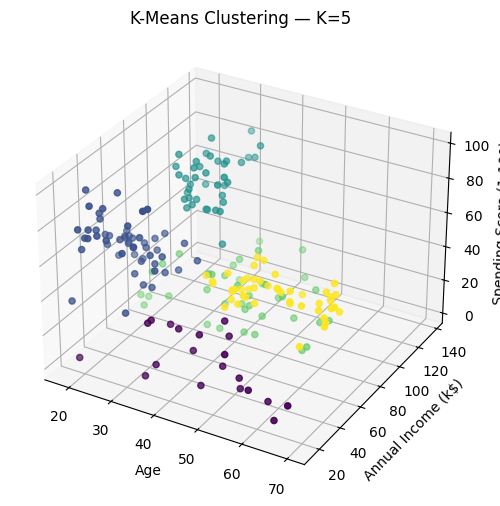

In [ ]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

labels = labels_dict[5]

ax.scatter(
    X['Age'],
    X['Annual Income (k$)'],
    X['Spending Score (1-100)'],
    c=labels
)

ax.set_xlabel('Age')
ax.set_ylabel('Annual Income (k$)')
ax.set_zlabel('Spending Score (1-100)')
ax.set_title('K-Means Clustering — K=5')

plt.show()

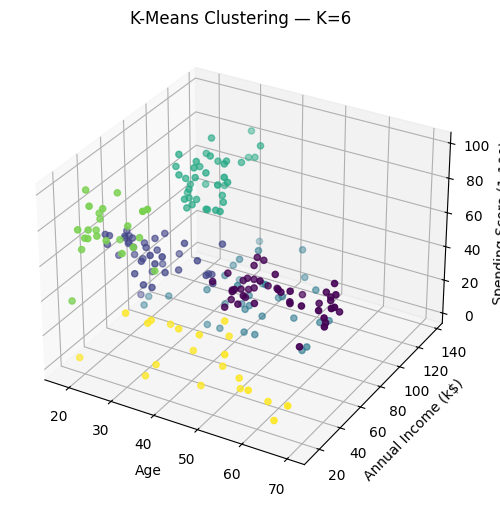

In [ ]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

labels = labels_dict[6]

ax.scatter(
    X['Age'],
    X['Annual Income (k$)'],
    X['Spending Score (1-100)'],
    c=labels
)

ax.set_xlabel('Age')
ax.set_ylabel('Annual Income (k$)')
ax.set_zlabel('Spending Score (1-100)')
ax.set_title('K-Means Clustering — K=6')

plt.show()

#Final Baseline Model (k=6):
##KMeans Clustering

In [ ]:
kmeans = KMeans(
    n_clusters=6,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(X_scaled)

df['KMeans_Cluster'] = kmeans_labels

df['KMeans_Cluster'].value_counts().sort_index()

,count
KMeans_Cluster,
0,45
1,39
2,33
3,39
4,23
5,21


In [ ]:
cluster_profile = df.groupby('KMeans_Cluster')[
    ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
].mean().round(2)

cluster_profile

,Age,Annual Income (k$),Spending Score (1-100)
KMeans_Cluster,,,
0,56.33,54.27,49.07
1,26.79,57.10,48.13
2,41.94,88.94,16.97
3,32.69,86.54,82.13
4,25.00,25.26,77.61
5,45.52,26.29,19.38


In [ ]:
cluster_median = df.groupby('KMeans_Cluster')[
    ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
].median().round(2)

cluster_median

,Age,Annual Income (k$),Spending Score (1-100)
KMeans_Cluster,,,
0,54.0,54.0,49.0
1,26.0,60.0,50.0
2,43.0,86.0,16.0
3,32.0,79.0,83.0
4,23.0,24.0,77.0
5,46.0,25.0,15.0


In [ ]:
gender_distribution = pd.crosstab(
    df['KMeans_Cluster'],
    df['Gender'],
    normalize='index'
).round(3) * 100

gender_distribution

Gender,Female,Male
KMeans_Cluster,,
0,57.8,42.2
1,64.1,35.9
2,42.4,57.6
3,53.8,46.2
4,56.5,43.5
5,61.9,38.1


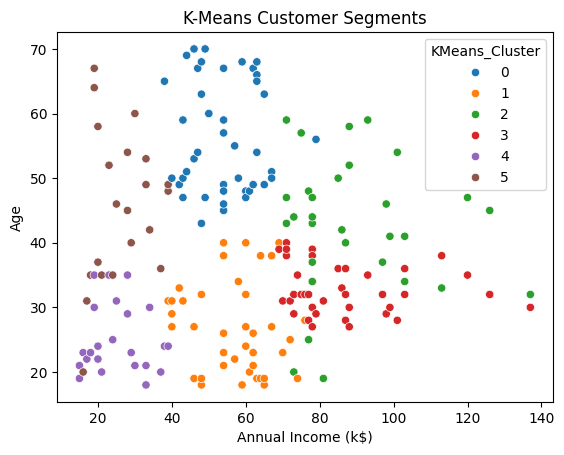

In [ ]:
sns.scatterplot(
    data=df,
    x='Annual Income (k$)',
    y='Age',
    hue='KMeans_Cluster',
    palette='tab10'
)

plt.title('K-Means Customer Segments')
plt.show()

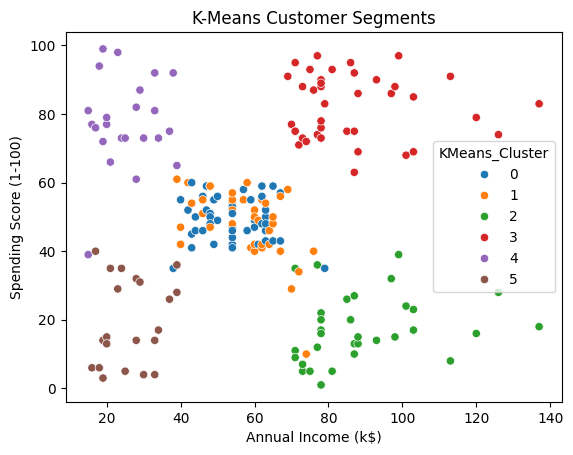

In [ ]:
sns.scatterplot(
    data=df,
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='KMeans_Cluster',
    palette='tab10'
)

plt.title('K-Means Customer Segments')
plt.show()

#Advanced Model Analysis #1:
##Agglomerative Clustering

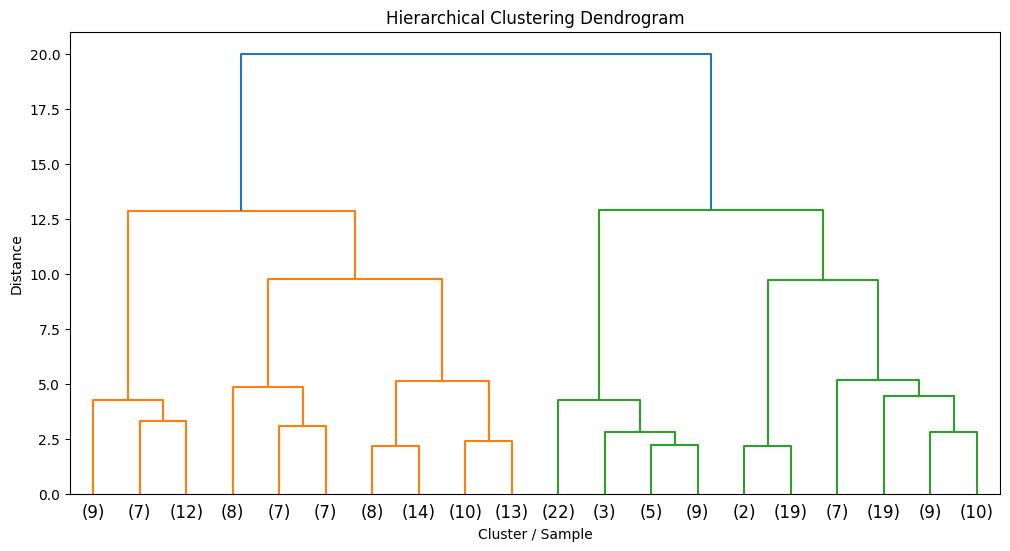

In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage

linked = linkage(X_scaled, method='ward')

plt.figure(figsize=(12, 6))

dendrogram(
    linked,
    truncate_mode='lastp',
    p=20
)

plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Cluster / Sample')
plt.ylabel('Distance')

plt.show()

In [ ]:
from sklearn.cluster import AgglomerativeClustering

agg_results = {}

for k in [4, 5, 6]:
    agg = AgglomerativeClustering(
        n_clusters=k,
        linkage='ward'
    )

    labels = agg.fit_predict(X_scaled)

    agg_results[k] = labels

In [ ]:
for k, labels in agg_results.items():

    silhouette = silhouette_score(X_scaled, labels)
    db = davies_bouldin_score(X_scaled, labels)
    ch = calinski_harabasz_score(X_scaled, labels)

    print(f"\nK={k}")
    print(f"Silhouette Score: {silhouette:.4f}")
    print(f"Davies-Bouldin Index: {db:.4f}")
    print(f"Calinski-Harabasz Index: {ch:.2f}")


K=4
Silhouette Score: 0.3615
Davies-Bouldin Index: 1.0164
Calinski-Harabasz Index: 102.02

K=5
Silhouette Score: 0.3900
Davies-Bouldin Index: 0.9163
Calinski-Harabasz Index: 107.83

K=6
Silhouette Score: 0.4201
Davies-Bouldin Index: 0.8521
Calinski-Harabasz Index: 127.99


In [ ]:
agg6 = AgglomerativeClustering(
    n_clusters=6,
    linkage='ward'
)

agg_labels = agg6.fit_predict(X_scaled)

df['Agg_Cluster'] = agg_labels

print(df['Agg_Cluster'].value_counts().sort_index())

agg_profile_mean = df.groupby('Agg_Cluster')[
    ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
].mean().round(2)

agg_profile_median = df.groupby('Agg_Cluster')[
    ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
].median().round(2)

print("Mean Profile:")
display(agg_profile_mean)

print("\nMedian Profile:")
display(agg_profile_median)

Agg_Cluster
0    45
1    45
2    39
3    28
4    22
5    21
Name: count, dtype: int64
Mean Profile:


,Age,Annual Income (k$),Spending Score (1-100)
Agg_Cluster,,,
0,27.38,57.51,45.84
1,56.40,55.29,48.36
2,32.69,86.54,82.13
3,43.89,91.29,16.68
4,44.32,25.77,20.27
5,24.81,25.62,80.24



Median Profile:


,Age,Annual Income (k$),Spending Score (1-100)
Agg_Cluster,,,
0,26.0,60.0,50.0
1,54.0,54.0,48.0
2,32.0,79.0,83.0
3,43.5,87.0,16.0
4,45.5,24.5,16.0
5,23.0,24.0,77.0


#Advanced Model Analysis #2:
##DBSCAN

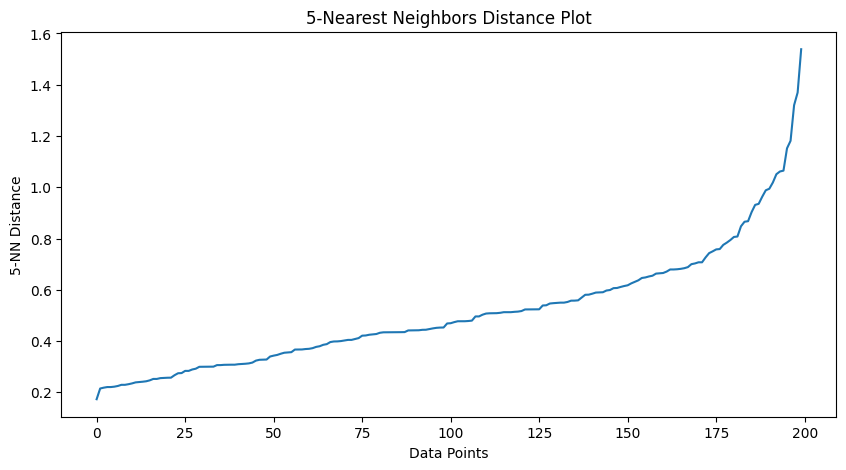

In [ ]:
from sklearn.neighbors import NearestNeighbors

neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_scaled)

distances, indices = neighbors_fit.kneighbors(X_scaled)

distances = np.sort(distances[:, -1])

plt.figure(figsize=(10, 5))
plt.plot(distances)

plt.title('5-Nearest Neighbors Distance Plot')
plt.xlabel('Data Points')
plt.ylabel('5-NN Distance')

plt.show()

In [ ]:
# Print selected k-distance values
for i in range(170, 200):
    print(f"Point {i}: {distances[i]:.4f}")

Point 170: 0.7072
Point 171: 0.7072
Point 172: 0.7263
Point 173: 0.7430
Point 174: 0.7500
Point 175: 0.7576
Point 176: 0.7589
Point 177: 0.7752
Point 178: 0.7840
Point 179: 0.7941
Point 180: 0.8061
Point 181: 0.8079
Point 182: 0.8478
Point 183: 0.8655
Point 184: 0.8676
Point 185: 0.9030
Point 186: 0.9312
Point 187: 0.9353
Point 188: 0.9631
Point 189: 0.9882
Point 190: 0.9942
Point 191: 1.0185
Point 192: 1.0509
Point 193: 1.0615
Point 194: 1.0649
Point 195: 1.1519
Point 196: 1.1811
Point 197: 1.3200
Point 198: 1.3695
Point 199: 1.5385


In [ ]:
eps_values = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
min_samples_values = [3, 4, 5, 6, 8]

dbscan_sensitivity = []

for min_samples in min_samples_values:

    for eps in eps_values:

        dbscan = DBSCAN(
            eps=eps,
            min_samples=min_samples
        )

        labels = dbscan.fit_predict(X_scaled)

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = np.sum(labels == -1)

        noise_pct = (n_noise / len(labels)) * 100

        mask = labels != -1

        if n_clusters >= 2 and mask.sum() > n_clusters:

            silhouette = silhouette_score(
                X_scaled[mask],
                labels[mask]
            )

            db = davies_bouldin_score(
                X_scaled[mask],
                labels[mask]
            )

            ch = calinski_harabasz_score(
                X_scaled[mask],
                labels[mask]
            )

        else:
            silhouette = np.nan
            db = np.nan
            ch = np.nan

        dbscan_sensitivity.append([
            eps,
            min_samples,
            n_clusters,
            n_noise,
            noise_pct,
            silhouette,
            db,
            ch
        ])

dbscan_sensitivity = pd.DataFrame(
    dbscan_sensitivity,
    columns=[
        'eps',
        'min_samples',
        'Clusters',
        'Noise Points',
        'Noise %',
        'Silhouette',
        'Davies-Bouldin',
        'Calinski-Harabasz'
    ]
)

display(dbscan_sensitivity.round(4))

,eps,min_samples,Clusters,Noise Points,Noise %,Silhouette,Davies-Bouldin,Calinski-Harabasz
0,0.5,3,8,32,16.0,0.2726,0.8190,36.3617
1,0.6,3,3,14,7.0,0.2149,0.9505,36.5072
2,0.7,3,2,7,3.5,0.1703,0.8063,7.0638
3,0.8,3,1,3,1.5,NaN,NaN,NaN
4,0.9,3,1,2,1.0,NaN,NaN,NaN
5,1.0,3,1,1,0.5,NaN,NaN,NaN
6,0.5,4,8,39,19.5,0.2815,0.8918,35.1914
7,0.6,4,3,18,9.0,0.2015,0.9460,32.6472
8,0.7,4,2,9,4.5,0.1761,0.7976,7.2579
9,0.8,4,1,5,2.5,NaN,NaN,NaN


#Dimensionality Reduction

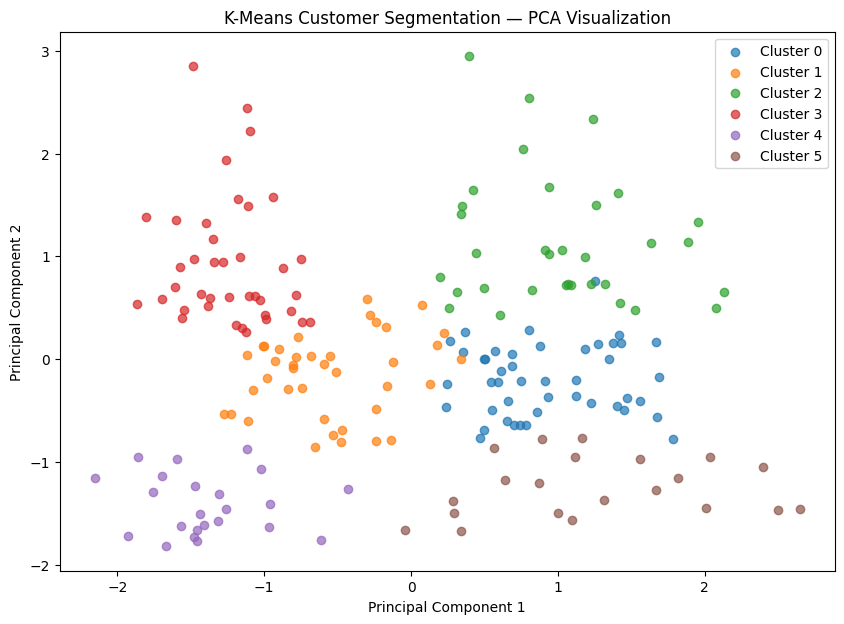

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    X_pca,
    columns=['PC1', 'PC2']
)

pca_df['Cluster'] = kmeans_labels

plt.figure(figsize=(10, 7))

for cluster in sorted(pca_df['Cluster'].unique()):
    cluster_data = pca_df[pca_df['Cluster'] == cluster]

    plt.scatter(
        cluster_data['PC1'],
        cluster_data['PC2'],
        label=f'Cluster {cluster}',
        alpha=0.7
    )

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('K-Means Customer Segmentation — PCA Visualization')
plt.legend()
plt.show()

In [ ]:
print("Explained variance ratio:")
print(pca.explained_variance_ratio_)

print(
    "Total explained variance:",
    pca.explained_variance_ratio_.sum()
)

Explained variance ratio:
[0.44266167 0.33308378]
Total explained variance: 0.7757454566976747


#Conclusion:

This project applied unsupervised machine learning techniques to segment mall customers based on their **Age, Annual Income, and Spending Score**. CustomerID was excluded because it is an identifier rather than a meaningful clustering feature, while Gender was retained for post-clustering analysis rather than being used to determine the clusters.

After exploratory data analysis and feature scaling using StandardScaler, K-Means clustering was evaluated across multiple values of K using the Elbow Method and Silhouette Score. Further evaluation using the Silhouette Score, Davies-Bouldin Index, and Calinski-Harabasz Index identified **K=6** as the most suitable configuration among the tested K-Means solutions.

The resulting six K-Means clusters represented distinct customer profiles, including younger and older middle-income customers with moderate spending, high-income customers with either high or low spending, and low-income customers with either high or low spending.

Agglomerative Clustering using Ward linkage was also evaluated. Its K=6 solution produced customer profiles that were highly similar to those discovered by K-Means, providing additional evidence that the identified customer structure was reasonably consistent across two different clustering approaches. K-Means achieved slightly stronger internal validation scores than Agglomerative Clustering at K=6.

DBSCAN was evaluated using different combinations of `eps` and `min_samples`. It either produced a single connected cluster or generated solutions with a relatively large proportion of observations classified as noise. Therefore, DBSCAN did not provide a stable and practically useful multi-cluster segmentation for this dataset.

Finally, PCA was used to visualize the K-Means clusters in two dimensions. The first two principal components explained approximately **77.57% of the total variance**, and the resulting visualization showed clear separation between the identified clusters.

Overall, the project demonstrates a complete unsupervised learning workflow and shows how different clustering algorithms, internal validation metrics, cluster profiling, and dimensionality reduction can be combined to identify and interpret customer segments.


#Steps Performed
## Steps Performed

1. **Loaded and inspected the dataset**

   * Examined the dataset shape, columns, data types, and descriptive statistics.
   * Dataset contained 200 customer records and 5 features.

2. **Performed exploratory data analysis**

   * Checked for missing values and duplicate records.
   * Examined numerical distributions using histograms and KDE plots.
   * Identified potential outliers using boxplots.
   * Examined correlations and pairwise relationships between numerical features.
   * Analyzed the distribution of the categorical Gender feature.

3. **Selected clustering features**

   * Excluded `CustomerID` because it is only an identifier.
   * Used `Age`, `Annual Income (k$)`, and `Spending Score (1-100)` as the primary clustering features.
   * Retained `Gender` for post-clustering customer profiling.

4. **Scaled the numerical features**

   * Applied `StandardScaler` so that all clustering features contributed on a comparable scale to distance-based algorithms.

5. **Determined the K-Means cluster count**

   * Tested K-Means for K values from 2 to 10.
   * Used the Elbow Method and Silhouette Score to identify promising values of K.
   * Further compared K=4, K=5, and K=6 using multiple internal validation metrics.

6. **Evaluated K-Means**

   * Calculated:

     * Silhouette Score
     * Davies-Bouldin Index
     * Calinski-Harabasz Index
   * Selected K=6 based on the combined internal evaluation results.

7. **Profiled the K-Means clusters**

   * Calculated mean and median values of Age, Annual Income, and Spending Score for each cluster.
   * Examined cluster sizes.
   * Analyzed Gender distribution across clusters.
   * Interpreted the resulting customer profiles.

8. **Applied Agglomerative Clustering**

   * Generated a hierarchical clustering dendrogram using Ward linkage.
   * Tested K=4, K=5, and K=6.
   * Evaluated each configuration using the same internal clustering metrics.

9. **Compared Agglomerative Clustering with K-Means**

   * Compared their validation metrics.
   * Profiled the Agglomerative K=6 clusters.
   * Found that both algorithms produced highly similar customer segments.

10. **Applied DBSCAN**

    * Generated a k-distance plot to investigate suitable `eps` values.
    * Tested multiple combinations of `eps` and `min_samples`.
    * Evaluated cluster counts, noise points, noise percentage, and internal validation metrics.
    * Found that DBSCAN did not produce a stable and interpretable multi-cluster solution for this dataset.

11. **Applied PCA for visualization**

    * Reduced the standardized three-dimensional feature space to two principal components.
    * PC1 explained approximately 44.27% of the variance.
    * PC2 explained approximately 33.31%.
    * Together, the first two components explained approximately **77.57%** of the total variance.
    * Visualized the K-Means clusters in two dimensions and observed clear separation between the clusters.

12. **Final model comparison**

    * Compared K-Means, Agglomerative Clustering, and DBSCAN based on internal validation, cluster structure, interpretability, and stability.
    * Used K-Means with K=6 as the primary segmentation because it produced strong internal validation results and clearly interpretable customer groups.
